# Week 2 — Data Exploration
**Internship:** IDX Exchange Data Science Program  
**Name:** Monika  
**Week:** 2  
**Dataset:** CRMLS Sold Properties (Jan 2022 – May 2026)

**Goal:** Load and explore the CRMLS sold property data to understand the structure, distributions, and relationships between features before building a price prediction model.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded!')

Libraries loaded!


## 1. Load All CSV Files
Loading all monthly CRMLSSold files and combining them into one dataframe.

In [10]:
data_folder = r'C:\Users\monik\OneDrive - University of Illinois - Urbana\Desktop\IDX Exchange_DS\data\california'

df1 = pd.read_csv(data_folder + r'\CRMLSSold20220101_20231231_filled.csv', low_memory=False)
df2 = pd.read_csv(data_folder + r'\CRMLSSold202401_filled.csv', low_memory=False)
df3 = pd.read_csv(data_folder + r'\CRMLSSold202402_filled.csv', low_memory=False)
df4 = pd.read_csv(data_folder + r'\CRMLSSold202403_filled.csv', low_memory=False)
df5 = pd.read_csv(data_folder + r'\CRMLSSold202404_filled.csv', low_memory=False)
df6 = pd.read_csv(data_folder + r'\CRMLSSold202405_filled.csv', low_memory=False)
df7 = pd.read_csv(data_folder + r'\CRMLSSold202406_filled.csv', low_memory=False)
df8 = pd.read_csv(data_folder + r'\CRMLSSold202407_filled.csv', low_memory=False)
df9 = pd.read_csv(data_folder + r'\CRMLSSold202408.csv', low_memory=False)
df10 = pd.read_csv(data_folder + r'\CRMLSSold202409.csv', low_memory=False)
df11 = pd.read_csv(data_folder + r'\CRMLSSold202410.csv', low_memory=False)
df12 = pd.read_csv(data_folder + r'\CRMLSSold202411.csv', low_memory=False)
df13 = pd.read_csv(data_folder + r'\CRMLSSold202412.csv', low_memory=False)
df14 = pd.read_csv(data_folder + r'\CRMLSSold202501_filled.csv', low_memory=False)
df15 = pd.read_csv(data_folder + r'\CRMLSSold202502.csv', low_memory=False)
df16 = pd.read_csv(data_folder + r'\CRMLSSold202503.csv', low_memory=False)
df17 = pd.read_csv(data_folder + r'\CRMLSSold202504.csv', low_memory=False)
df18 = pd.read_csv(data_folder + r'\CRMLSSold202505.csv', low_memory=False)
df19 = pd.read_csv(data_folder + r'\CRMLSSold202506.csv', low_memory=False)
df20 = pd.read_csv(data_folder + r'\CRMLSSold202507.csv', low_memory=False)
df21 = pd.read_csv(data_folder + r'\CRMLSSold202508.csv', low_memory=False)
df22 = pd.read_csv(data_folder + r'\CRMLSSold202509.csv', low_memory=False)
df23 = pd.read_csv(data_folder + r'\CRMLSSold202510.csv', low_memory=False)
df24 = pd.read_csv(data_folder + r'\CRMLSSold202511.csv', low_memory=False)
df25 = pd.read_csv(data_folder + r'\CRMLSSold202512.csv', low_memory=False)
df26 = pd.read_csv(data_folder + r'\CRMLSSold202601.csv', low_memory=False)
df27 = pd.read_csv(data_folder + r'\CRMLSSold202602.csv', low_memory=False)
df28 = pd.read_csv(data_folder + r'\CRMLSSold202603.csv', low_memory=False)
df29 = pd.read_csv(data_folder + r'\CRMLSSold202604.csv', low_memory=False)
df30 = pd.read_csv(data_folder + r'\CRMLSSold202605.csv', low_memory=False)

df_raw = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10,
                    df11, df12, df13, df14, df15, df16, df17, df18, df19, df20,
                    df21, df22, df23, df24, df25, df26, df27, df28, df29, df30],
                    ignore_index=True)

print(f'Total rows loaded: {len(df_raw):,}')
print(f'Total columns: {len(df_raw.columns)}')

Total rows loaded: 794,271
Total columns: 82


## 2. Filter to Single Family Residences
Per task requirements, keeping only PropertyType = Residential and PropertySubType = SingleFamilyResidence.

In [11]:
df = df_raw[
    (df_raw['PropertyType'] == 'Residential') &
    (df_raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'Rows before filter: {len(df_raw):,}')
print(f'Rows after filter:  {len(df):,}')
print(f'Rows removed: {len(df_raw) - len(df):,}')

Rows before filter: 794,271
Rows after filter:  399,157
Rows removed: 395,114


## 3. Basic Dataset Overview
Quick look at the structure and the key columns I'll be working with.

In [12]:
df.head()

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,...,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,NaN,NaN
6,NaN,True,NaN,NaN,False,565000.0,556365286,joseph@labelrealtygroup.com,2022-01-10,640000.0,...,1.0,Rim of the World,92352,0.0,3397.0,NaN,False,False,NaN,NaN
7,NaN,False,NaN,NaN,False,349999.0,556365284,eaguayo08@gmail.com,2022-03-23,438000.0,...,2.0,Fontana Unified,92336,0.0,9900.0,NaN,False,False,NaN,NaN
12,"Carpet,Tile",True,NaN,NaN,True,599000.0,556364261,gcrb714@gmail.com,2022-01-10,615000.0,...,2.0,NaN,92234,195.0,6098.0,NaN,False,False,NaN,NaN
14,NaN,True,NaN,NaN,False,399990.0,556363890,allegra@3treehomes.com,2022-01-19,399990.0,...,2.0,Paradise Unified,95969,0.0,12197.0,NaN,False,False,NaN,NaN


In [13]:
key_cols = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
            'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres',
            'YearBuilt', 'DaysOnMarket', 'Latitude', 'Longitude']

df[key_cols].describe().round(2)

,ClosePrice,ListPrice,OriginalListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeAcres,YearBuilt,DaysOnMarket,Latitude,Longitude
count,3.991550e+05,3.991570e+05,3.983780e+05,398947.00,399157.00,399082.00,392270.00,398849.00,399157.00,398964.00,398964.00
mean,1.285092e+06,1.248959e+06,1.336880e+06,2036.72,3.48,2.61,31.60,1975.39,34.27,34.81,-118.69
std,5.237207e+06,1.559621e+06,6.990745e+06,3803.28,0.96,1.18,12522.49,27.42,52.54,1.99,3.03
min,0.000000e+00,4.500000e+02,0.000000e+00,0.00,0.00,0.00,0.00,1776.00,-265.00,-117.47,-177.65
25%,6.200000e+05,6.190000e+05,6.250000e+05,1373.00,3.00,2.00,0.13,1955.00,7.00,33.77,-119.86
50%,8.890000e+05,8.800000e+05,8.950000e+05,1800.00,3.00,2.00,0.17,1975.00,16.00,34.10,-118.06
75%,1.425000e+06,1.399000e+06,1.400000e+06,2417.50,4.00,3.00,0.24,1997.00,43.00,35.35,-117.27
max,9.895000e+08,2.450000e+08,1.390000e+09,2308680.00,45.00,175.00,7810698.36,2026.00,12430.00,564.00,329.00


## 4. Missing Values Check
Checking how much data is missing in the columns I care about most.

In [14]:
missing = df[key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

                       Missing Count  Missing %
ClosePrice                         2        0.0
ListPrice                          0        0.0
OriginalListPrice                779        0.2
LivingArea                       210        0.1
BedroomsTotal                      0        0.0
BathroomsTotalInteger             75        0.0
LotSizeAcres                    6887        1.7
YearBuilt                        308        0.1
DaysOnMarket                       0        0.0
Latitude                         193        0.0
Longitude                        193        0.0


## 5. ClosePrice Distribution
ClosePrice is my target variable. I want to understand its spread, skew, and typical range.

Rows with a valid ClosePrice: 399,154


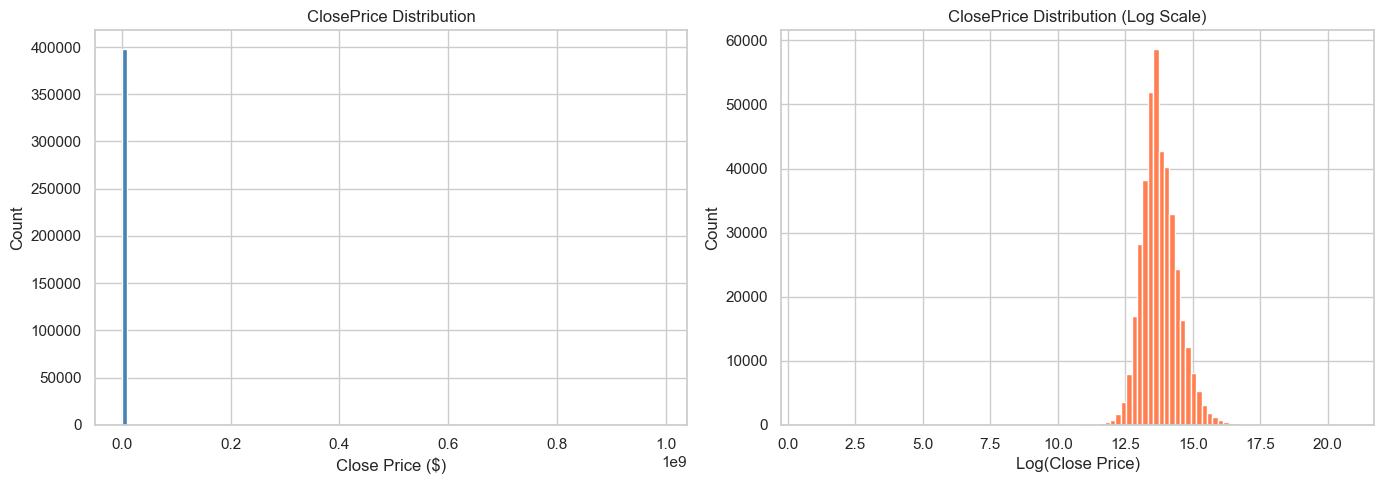

Median ClosePrice: $889,000
Mean ClosePrice:   $1,285,096
Min: $1 | Max: $989,500,000


In [16]:
df_sold = df[df['ClosePrice'].notna() & (df['ClosePrice'] > 0)].copy()
print(f'Rows with a valid ClosePrice: {len(df_sold):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sold['ClosePrice'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('ClosePrice Distribution')
axes[0].set_xlabel('Close Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df_sold['ClosePrice']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('ClosePrice Distribution (Log Scale)')
axes[1].set_xlabel('Log(Close Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Median ClosePrice: ${df_sold["ClosePrice"].median():,.0f}')
print(f'Mean ClosePrice:   ${df_sold["ClosePrice"].mean():,.0f}')
print(f'Min: ${df_sold["ClosePrice"].min():,.0f} | Max: ${df_sold["ClosePrice"].max():,.0f}')

## 6. LivingArea Distribution

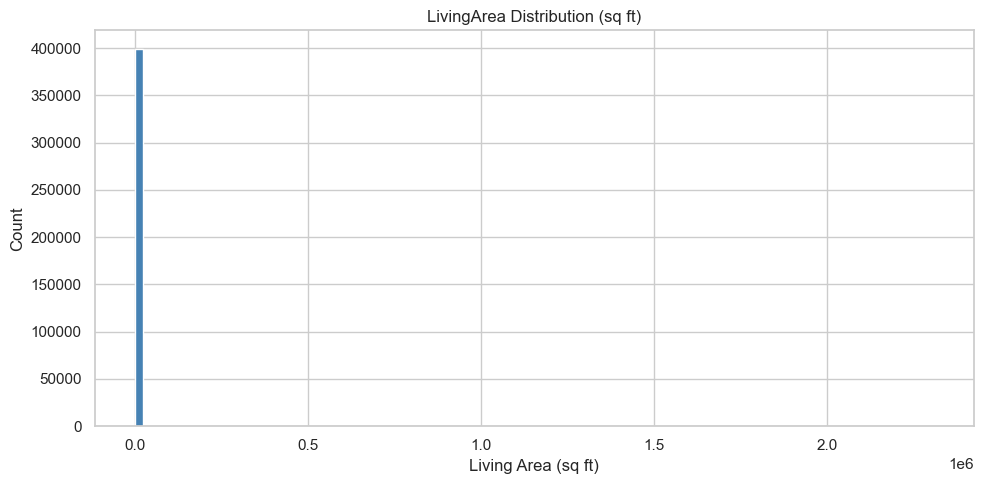

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
df_sold['LivingArea'].dropna().hist(bins=100, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('LivingArea Distribution (sq ft)')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 7. Bedrooms & Bathrooms Distribution

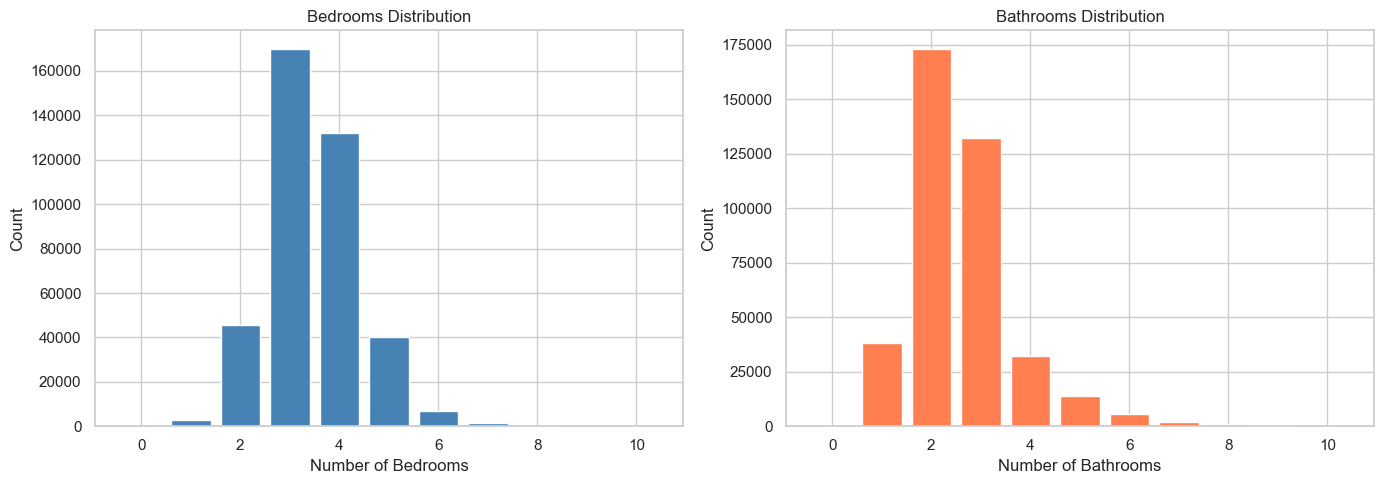

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bed_counts = df_sold['BedroomsTotal'].value_counts().sort_index()
bed_counts = bed_counts[bed_counts.index <= 10]
axes[0].bar(bed_counts.index, bed_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Bedrooms Distribution')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Count')

bath_counts = df_sold['BathroomsTotalInteger'].value_counts().sort_index()
bath_counts = bath_counts[bath_counts.index <= 10]
axes[1].bar(bath_counts.index, bath_counts.values, color='coral', edgecolor='white')
axes[1].set_title('Bathrooms Distribution')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 8. LotSize Distribution

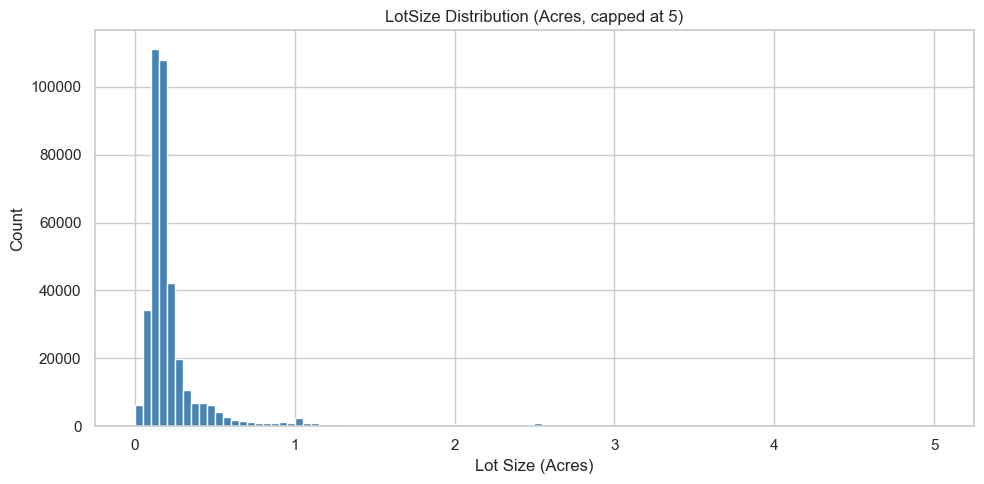

In [19]:
lot_data = df_sold[df_sold['LotSizeAcres'] < 5]['LotSizeAcres'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
lot_data.hist(bins=100, color='steelblue', edgecolor='white', ax=ax)
ax.set_title('LotSize Distribution (Acres, capped at 5)')
ax.set_xlabel('Lot Size (Acres)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 9. ClosePrice vs Key Features
Scatter plots to check relationships between features and the target variable.

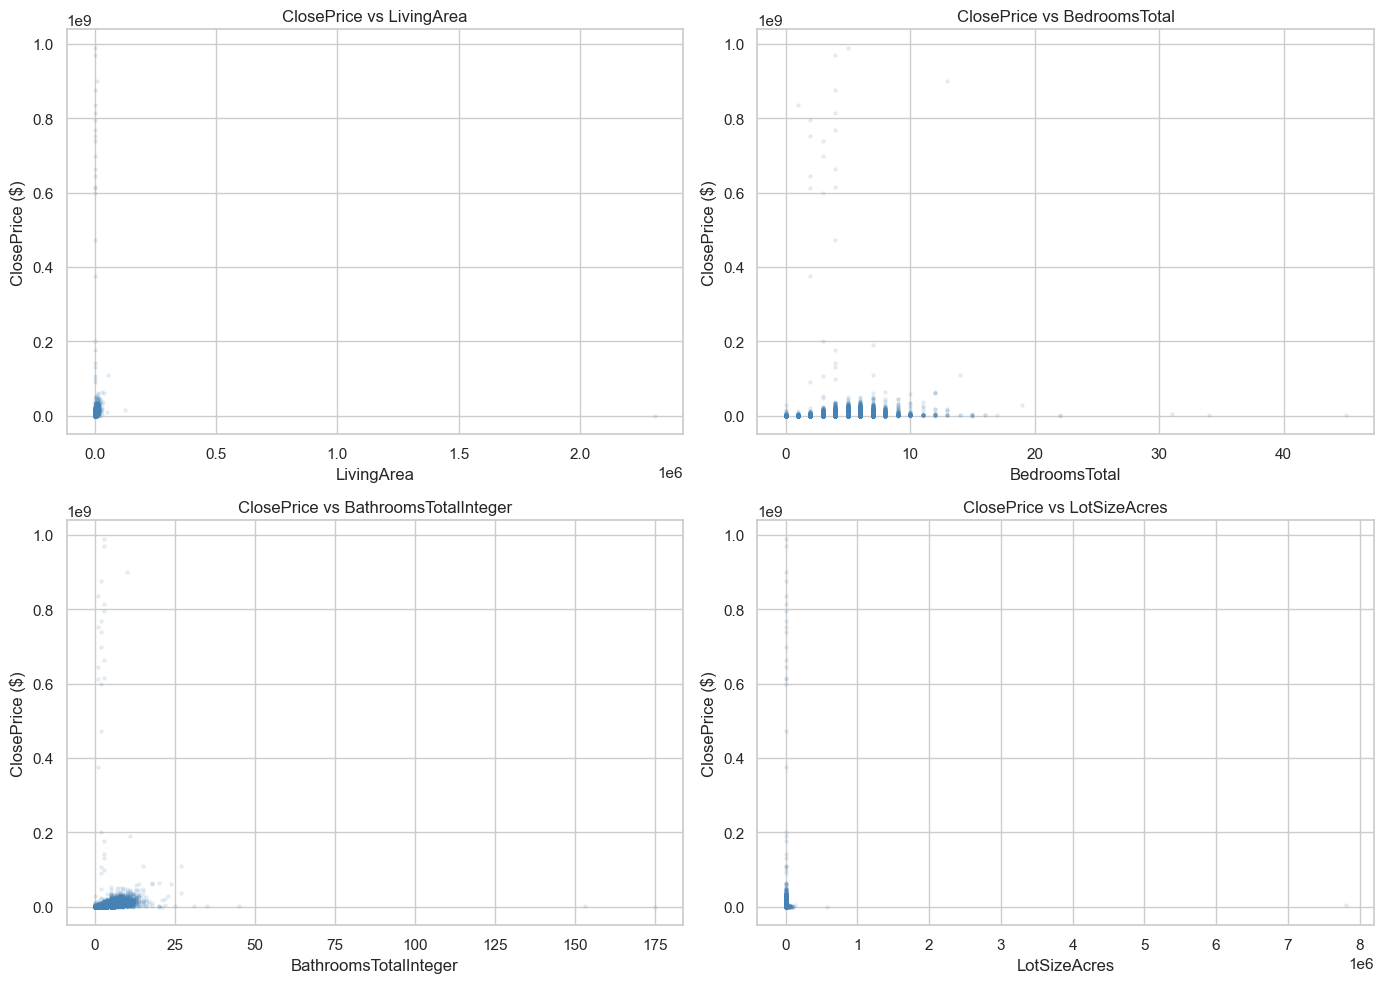

In [20]:
features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    data = df_sold[[feat, 'ClosePrice']].dropna()
    axes[i].scatter(data[feat], data['ClosePrice'], alpha=0.1, color='steelblue', s=5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('ClosePrice ($)')
    axes[i].set_title(f'ClosePrice vs {feat}')

plt.tight_layout()
plt.show()

## 10. Correlation Heatmap
Checking which features are most correlated with ClosePrice.

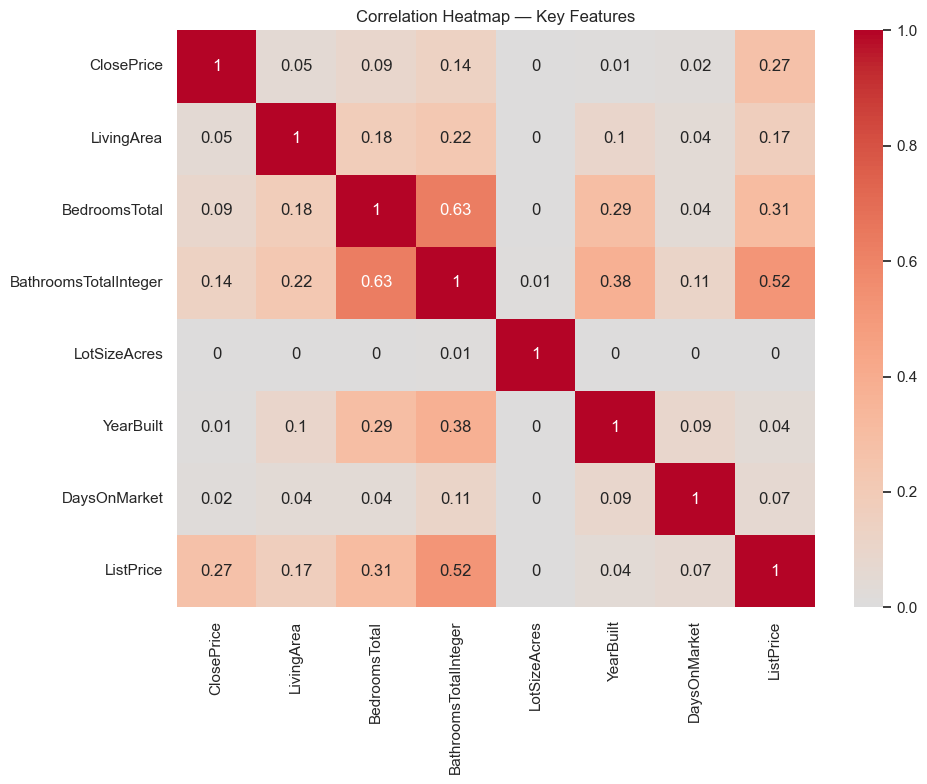

In [21]:
corr_cols = ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger',
             'LotSizeAcres', 'YearBuilt', 'DaysOnMarket', 'ListPrice']

corr_matrix = df_sold[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Key Features')
plt.tight_layout()
plt.show()

## 11. Median ClosePrice Over Time
Checking how prices have trended month by month.

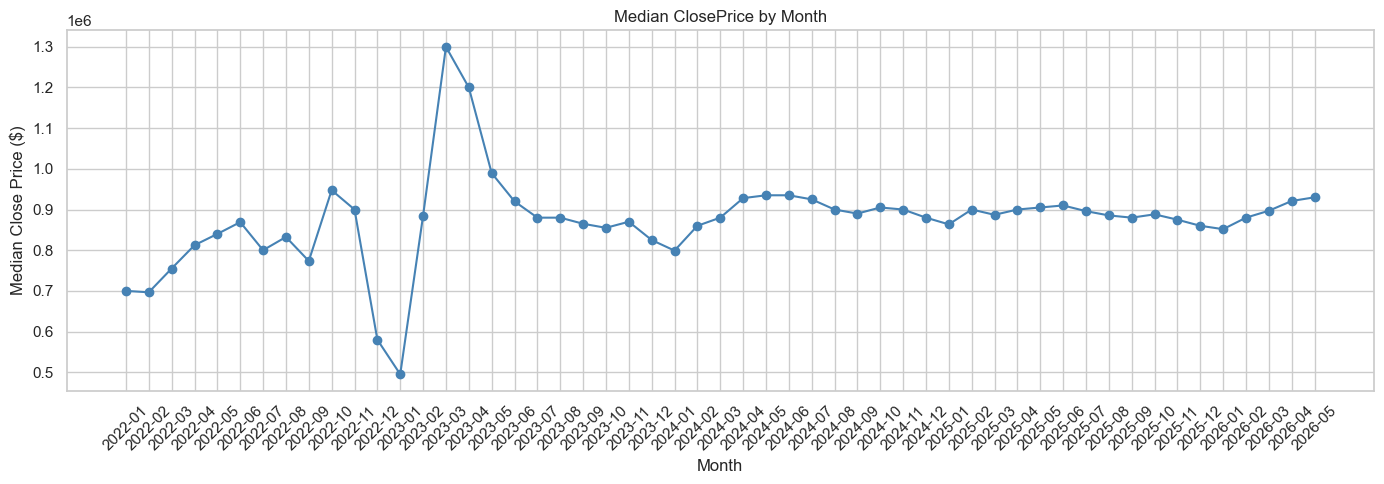

In [22]:
df_sold['CloseDate'] = pd.to_datetime(df_sold['CloseDate'], errors='coerce')
df_sold['YearMonth'] = df_sold['CloseDate'].dt.to_period('M')

monthly = df_sold.groupby('YearMonth')['ClosePrice'].median().reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['YearMonth'], monthly['ClosePrice'], marker='o', color='steelblue')
ax.set_title('Median ClosePrice by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Median Close Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. Summary of Findings

- **ClosePrice** is right-skewed — a log transformation may help the model later.
- **LivingArea** has a clear positive relationship with ClosePrice.
- Most homes have **3-4 bedrooms** and **2-3 bathrooms**.
- **LotSizeAcres** is heavily skewed with some large outlier lots.
- **ListPrice** is the most correlated feature with ClosePrice.
- There are missing values in several columns — will handle in Week 3.